# Домашнее задание №5.
**Проект:** Сервис для сегментации опухолей на МРТ головного мозга с системой поиска похожих случаев.

In [1]:
!pip install --upgrade pip --quiet
!pip install pandas numpy matplotlib seaborn torch torchvision tqdm scikit-image opencv-python --quiet

In [1]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from tqdm import tqdm
from skimage.io import imread

### 1. Загрузка и очистка данных

Обходим все папки с нашим датасетом, находим все снимки МРТ и маски (разметку опухолей), и сохраняем точные пути к ним. Сортировка гарантирует, что каждый снимок МРТ будет строго соответствовать своей маске.

In [4]:
DATA_PATH = "/Users/nastik/Downloads/archive/kaggle_3m"

images_paths = []
masks_paths = []

for root, dirs, files in os.walk(DATA_PATH):
    for name in files:
        if name.endswith('.tif'):
            if 'mask' in name:
                masks_paths.append(os.path.join(root, name))
            else:
                images_paths.append(os.path.join(root, name))

images_paths.sort()
masks_paths.sort()

print(f"Найдено изображений (МРТ): {len(images_paths)}")
print(f"Найдено масок (разметка): {len(masks_paths)}")

Найдено изображений (МРТ): 3929
Найдено масок (разметка): 3929


В датасете найдено **3929** МРТ-изображений и **3929** масок. Это означает, что разметка полная и количество масок в точности соответствует количеству снимков.

### 2. Анализ данных:
#### 2.1 Анализ размеров снимков и проверка валидности данных
Проанализруем сколько уникальных пациентов в датасете, какого размера представлены изображения, и нет ли среди них "битых" полностью черных снимков.

Анализ размеров изображений: 100%|██████████| 3929/3929 [00:03<00:00, 1012.21it/s]


Всего уникальных пациентов: 110


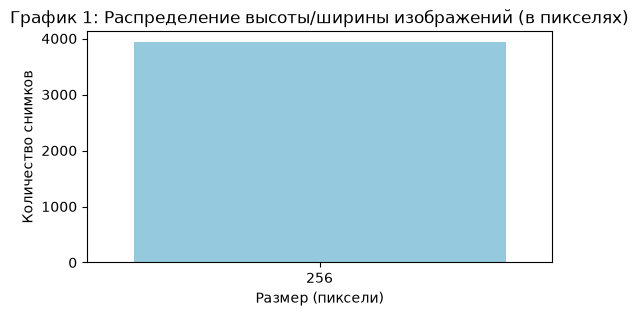

Уникальные размеры изображений в датасете:
   Height  Width  Channels
0     256    256         3


Проверка валидности масок: 100%|██████████| 3929/3929 [00:01<00:00, 2322.69it/s]

Полностью черных изображений (ошибки данных): 0
Полностью черных масок (срезы без опухоли): 2556


In [5]:
patient_ids = set()
image_shapes = []

for path in tqdm(images_paths, desc="Анализ размеров изображений"):
    patient_id = path.split(os.sep)[-2]
    patient_ids.add(patient_id)
    
    img = imread(path)
    image_shapes.append(img.shape)

print(f"Всего уникальных пациентов: {len(patient_ids)}")

df_shapes = pd.DataFrame(image_shapes, columns=['Height', 'Width', 'Channels'])

plt.figure(figsize=(6, 3))
sns.countplot(x='Height', data=df_shapes, color='skyblue')
plt.title("График 1: Распределение высоты/ширины изображений (в пикселях)")
plt.xlabel("Размер (пиксели)")
plt.ylabel("Количество снимков")
plt.show()

print("Уникальные размеры изображений в датасете:")
print(df_shapes.drop_duplicates())

black_images = 0
black_masks = 0

for path in tqdm(images_paths, desc="Проверка валидности изображений"):
    img = imread(path)
    if np.all(img == 0):
        black_images += 1

for path in tqdm(masks_paths, desc="Проверка валидности масок"):
    mask = imread(path, as_gray=True)
    if np.all(mask == 0):
        black_masks += 1

print(f"Полностью черных изображений (ошибки данных): {black_images}")
print(f"Полностью черных масок (срезы без опухоли): {black_masks}")

В наборе данных представлены **110** пациентов, чьи снимки дают в сумме 3929 2D-срезов.
Гистограмма показала, что все изображения уже приведены к единому размеру **256×256** пикселей. Это особенность именно этого Kaggle датасета, так как авторы заранее сделали предобработку и привели снимки к стандартному формату. Нормализация по размеру на данном этапе не требуется.

Битых (полностью черных) МРТ-снимков не найдено (**0** штук).
Найдено **2556** полностью черных масок. Это не ошибка разметки, а означает, что на этих конкретных срезах мозга опухоль отсутствует (фон), что является нормальной клинической картиной.

#### 2.2 Проанализируем, сколько срезов в среднем приходится на **одного** человека и сколько из этих срезов содержат опухоль

Анализ срезов по пациентам: 100%|██████████| 3929/3929 [00:00<00:00, 4802.51it/s]


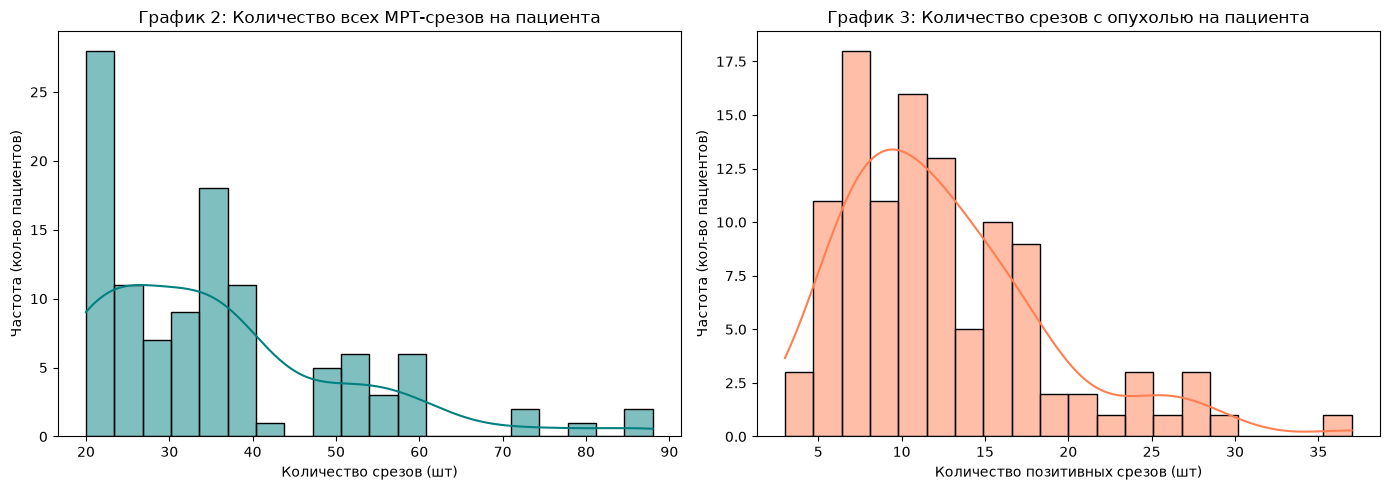

In [6]:
slices_per_patient_dict = {}
positive_slices_per_patient_dict = {}

for img_path, mask_path in tqdm(zip(images_paths, masks_paths), total=len(masks_paths), desc="Анализ срезов по пациентам"):
    patient_id = img_path.split(os.sep)[-2]
    mask = imread(mask_path, as_gray=True)
    has_tumor = 1 if np.sum(mask > 0) > 0 else 0
    
    slices_per_patient_dict[patient_id] = slices_per_patient_dict.get(patient_id, 0) + 1
    
    positive_slices_per_patient_dict[patient_id] = positive_slices_per_patient_dict.get(patient_id, 0) + has_tumor

total_slices = list(slices_per_patient_dict.values())
positive_slices = list(positive_slices_per_patient_dict.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 2: Сколько всего срезов сделали одному пациенту
sns.histplot(total_slices, bins=20, ax=axes[0], color='teal', kde=True)
axes[0].set_title('График 2: Количество всех МРТ-срезов на пациента')
axes[0].set_xlabel('Количество срезов (шт)')
axes[0].set_ylabel('Частота (кол-во пациентов)')

# График 3: Сколько позитивных срезов (с опухолью) у одного пациента
sns.histplot(positive_slices, bins=20, ax=axes[1], color='coral', kde=True)
axes[1].set_title('График 3: Количество срезов с опухолью на пациента')
axes[1].set_xlabel('Количество позитивных срезов (шт)')
axes[1].set_ylabel('Частота (кол-во пациентов)')

plt.tight_layout()
plt.show()

**График 2** показывает, что количество срезов варьируется в зависимости от аппарата МРТ. У большинства пациентов от 20 до 40 срезов.

**График 3** показывает размер самой опухоли. У большинства пациентов опухоль захватывает от 5 до 15 срезов. Однако есть пациенты, у которых опухоль присутствует более чем на 30 срезах (очень крупные опухоли). 

#### 2.3 Проанализируем, насколько часто на срезах присутствует опухоль и какую площадь занимает

Анализ масок на дисбаланс: 100%|██████████| 3929/3929 [00:00<00:00, 4852.11it/s]


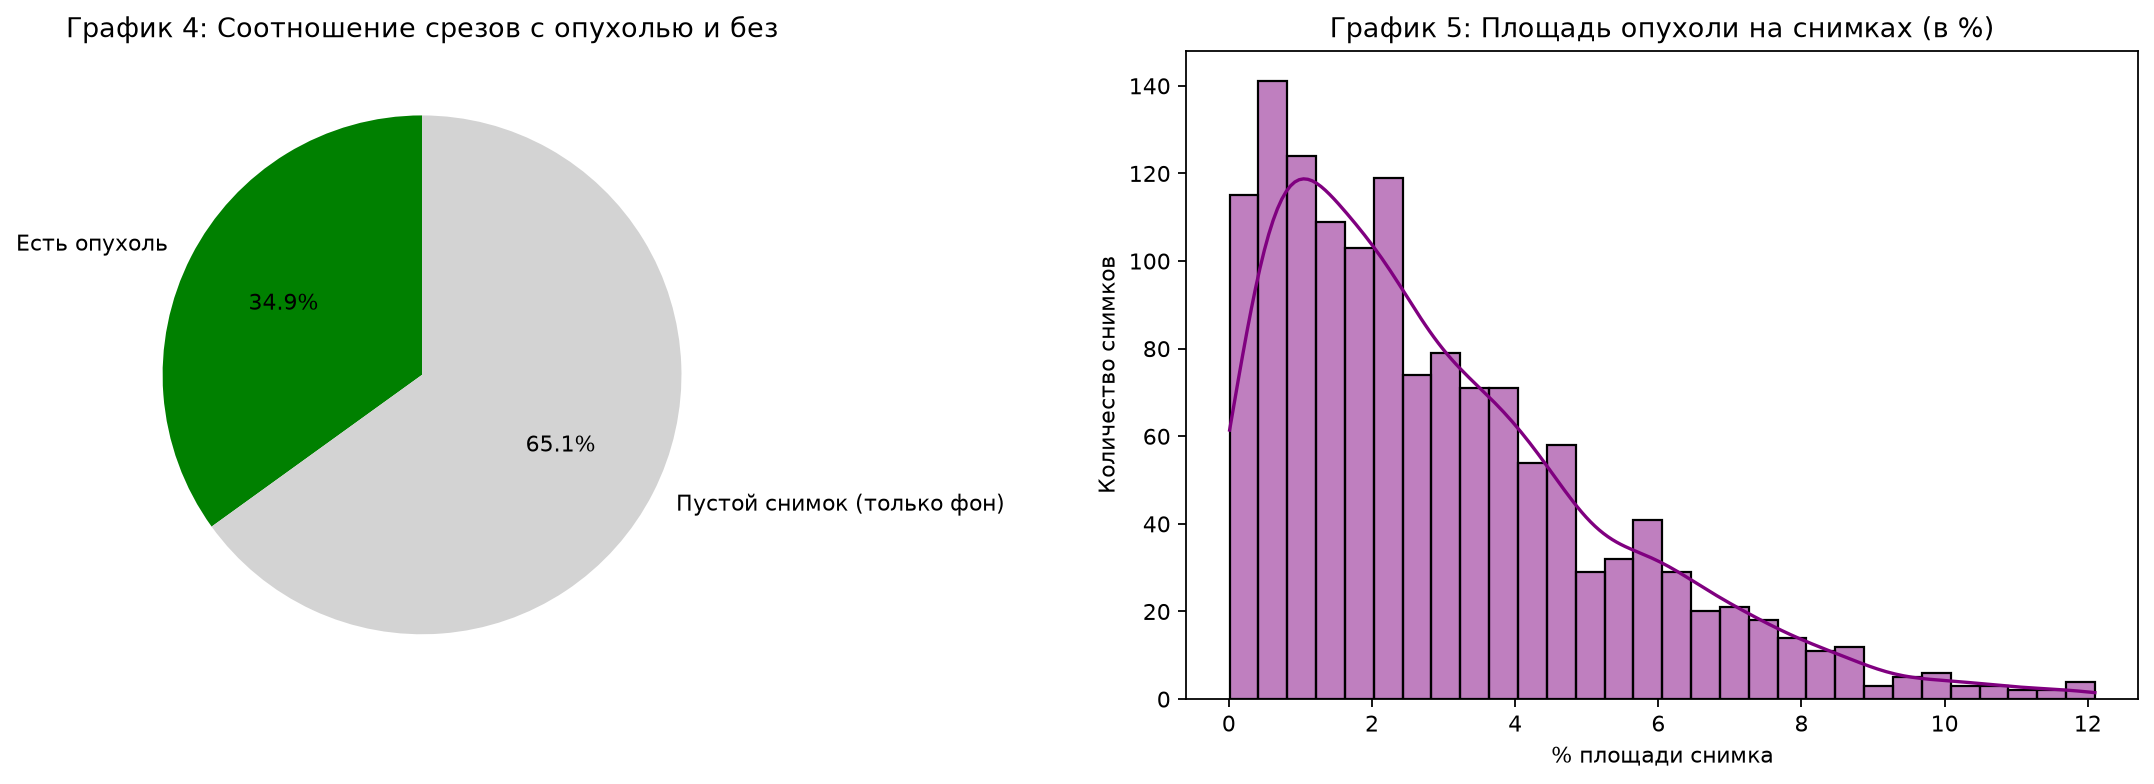

In [7]:
has_tumor_count = 0
empty_mask_count = 0
tumor_area_percentages = []

for path in tqdm(masks_paths, desc="Анализ масок на дисбаланс"):
    mask = imread(path, as_gray=True)
    
    total_pixels = mask.size
    tumor_pixels = np.sum(mask > 0)
    
    if tumor_pixels > 0:
        has_tumor_count += 1
        percentage = (tumor_pixels / total_pixels) * 100
        tumor_area_percentages.append(percentage)
    else:
        empty_mask_count += 1

plt.figure(figsize=(14, 5), dpi=160)

# График 4: Круговая диаграмма баланса классов
plt.subplot(1, 2, 1)
plt.pie([has_tumor_count, empty_mask_count], 
        labels=['Есть опухоль', 'Пустой снимок (только фон)'], 
        autopct='%1.1f%%', colors=['green', 'lightgrey'], startangle=90)
plt.title("График 4: Соотношение срезов с опухолью и без")

# График 5: Гистограмма площади опухоли
plt.subplot(1, 2, 2)
sns.histplot(tumor_area_percentages, bins=30, kde=True, color='purple')
plt.title("График 5: Площадь опухоли на снимках (в %)")
plt.xlabel("% площади снимка")
plt.ylabel("Количество снимков")

plt.tight_layout()
plt.show()


**График 4** показывает дисбаланс данных: около 65% всех МРТ-срезов в датасете не содержат опухоли (являются чистым фоном). 

**График 5** демонстрирует дисбаланс уже внутри самих позитивных снимков. Даже если опухоль присутствует на кадре, она чаще всего занимает крошечную область — от 0.5% до 3% площади снимка.

**Вывод:** Из-за такого сильного дисбаланса стандартная метрика Accuracy (доля правильных ответов) нам не подходит, так как предсказание всегда черного экрана даст ложную точность в 65%+. Необходимо использовать метрику **Dice Coefficient**, а для обучения нейросети применять основанную на ней функцию **Dice Loss**. Также График 5 доказывает необходимость обрезки пустого черного фона вокруг мозга перед подачей в нейросеть.

#### 2.4 Проанализируем распределение яркости МРТ-снимков (на примере 3)

На примере нескольких случайных МРТ-снимков посмотрим, насколько сильно отличается их контрастность и яркость (интенсивность пикселей). Это поможет понять, нужна ли нам стандартизация яркости перед обучением нейросети.

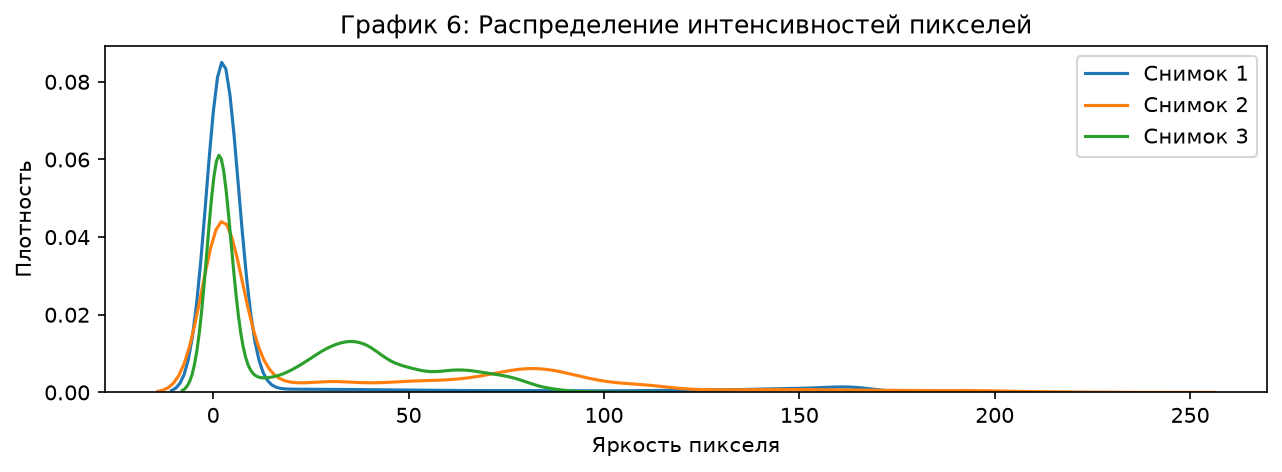

In [8]:
plt.figure(figsize=(10, 3), dpi=150)

sample_images = random.sample(images_paths, 3)

for i, path in enumerate(sample_images):
    img = imread(path)
    pixels = img[:,:,0].flatten()
    pixels_no_background = pixels[pixels > 0]
    
    sns.kdeplot(pixels_no_background, label=f"Снимок {i+1}")

plt.title("График 6: Распределение интенсивностей пикселей")
plt.xlabel("Яркость пикселя")
plt.ylabel("Плотность")
plt.legend()
plt.show()


График 6 наглядно показывает, что кривые плотности яркости пикселей для разных МРТ-снимков не совпадают (имеют разные пики и размах). Это могло произойти из-за того, что данные собирались с различных томографов с разными настройками.

**Вывод:** Подавать сырые снимки в нейросеть нельзя, она не сможет выучить единые признаки опухоли из-за скачков яркости. Потребуется сделать нормализацию интенсивностей.

#### 2.5 Визуализация конкретного примера (МРТ + Маска)

Убедимся в корректности разметки. Посмотрим на случайный снимок мозга и соответствующую ему маску опухоли.

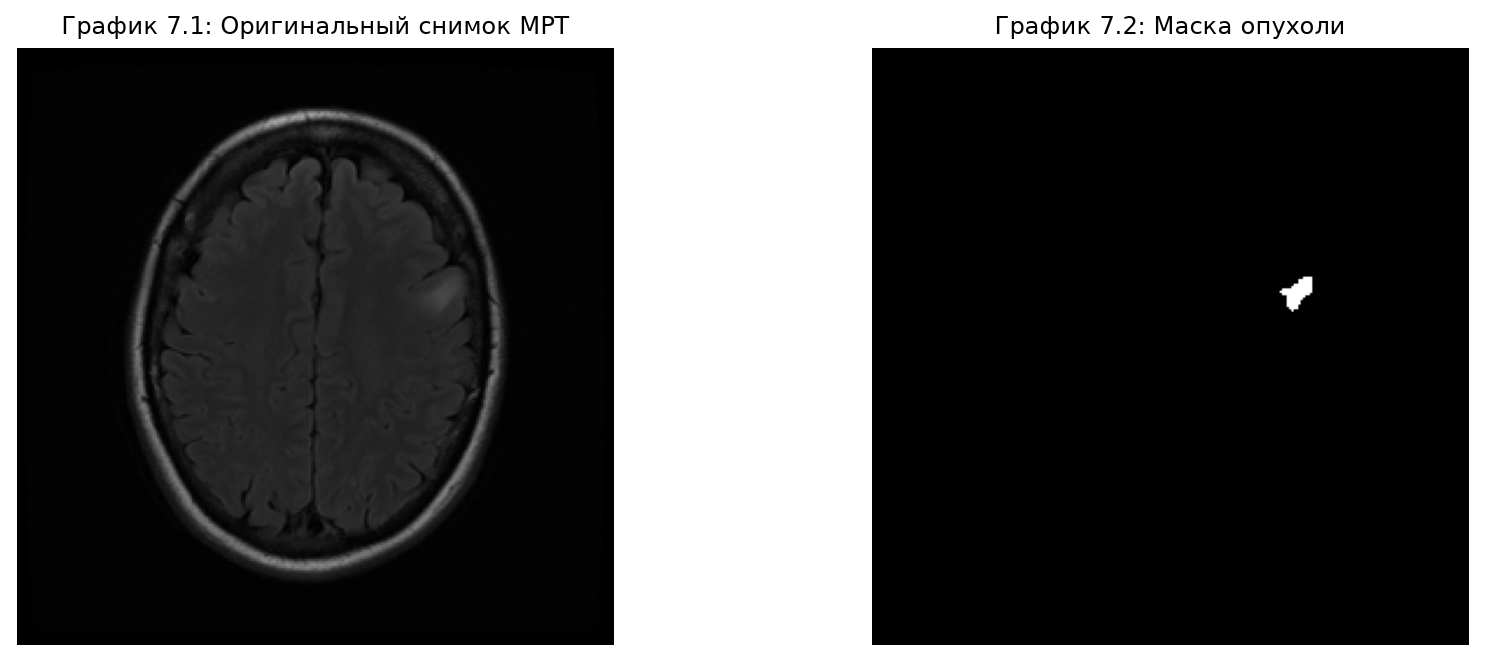

In [9]:
random.seed(42)

positive_samples = []
for p in masks_paths:
    if np.sum(imread(p, as_gray=True) > 0) > 0:
        positive_samples.append(p)

sample_mask_path = random.choice(positive_samples)
sample_img_path = sample_mask_path.replace('_mask', '')

img = imread(sample_img_path)
mask = imread(sample_mask_path, as_gray=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=170)
axes[0].imshow(img)
axes[0].set_title('График 7.1: Оригинальный снимок МРТ', fontsize=10)
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title('График 7.2: Маска опухоли', fontsize=10)
axes[1].axis('off')

plt.tight_layout()
plt.show()

По визуальному осмотру видно, что маска выделяет область повышенной интенсивности на снимке МРТ, соответствующую опухоли. Это подтверждает качество разметки.

### 3. Выбор и обучение моделей

В этом разделе сравниваются две архитектуры сегментации опухолей:
- **Простая модель:** Базовый UNet, обученный с нуля.
- **Усложненная модель:** UnetPlusPlus с предобученным энкодером EfficientNet-b3, обучением в 2 этапа (замороженный энкодер + последующий fine-tuning).

In [ ]:
!pip install segmentation-models-pytorch --quiet

In [ ]:
import gc
import random
import torch
import os
import torch.nn as nn
from collections import OrderedDict
import numpy as np
from torch.utils.data import Dataset, DataLoader
import pickle
import kagglehub
from pathlib import Path
from skimage.io import imread
from skimage.transform import resize
from tqdm import tqdm
from segmentation_models_pytorch.encoders import get_preprocessing_fn

import torch.optim as optim
import segmentation_models_pytorch as smp
import albumentations as A
import torchvision.transforms as T

def free_memory(*objects_to_delete):
    for obj in objects_to_delete:
        if obj in locals() or obj in globals():
            del obj

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        
    print("Память очищена")

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"Все сиды зафиксированы на числе {seed}.")

seed_everything(42)

Все сиды зафиксированы на числе 42.


In [4]:
try:
    download_path_str = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")
except Exception as e:
    print(f"Не удалось скачать датасет: {e}")
    raise

download_dir = Path(download_path_str)
DATA_PATH = download_dir / "kaggle_3m"
print(f"Датасет найден по пути: {DATA_PATH}")

working_dir = Path.cwd()
CACHE_FILE = working_dir / "dataset_cache.pkl"
IMAGE_SIZE = 160


def crop_sample(x):
    volume, mask = x
    volume[volume < np.max(volume) * 0.1] = 0
    z_projection = np.max(np.max(np.max(volume, axis=-1), axis=-1), axis=-1)
    z_nonzero = np.nonzero(z_projection)
    z_min, z_max = np.min(z_nonzero), np.max(z_nonzero) + 1
    y_projection = np.max(np.max(np.max(volume, axis=0), axis=-1), axis=-1)
    y_nonzero = np.nonzero(y_projection)
    y_min, y_max = np.min(y_nonzero), np.max(y_nonzero) + 1
    x_projection = np.max(np.max(np.max(volume, axis=0), axis=0), axis=-1)
    x_nonzero = np.nonzero(x_projection)
    x_min, x_max = np.min(x_nonzero), np.max(x_nonzero) + 1
    return volume[z_min:z_max, y_min:y_max, x_min:x_max], mask[z_min:z_max, y_min:y_max, x_min:x_max]


def pad_sample(x):
    volume, mask = x
    a, b = volume.shape[1], volume.shape[2]
    if a == b:
        return volume, mask
    diff = (max(a, b) - min(a, b)) / 2.0
    if a > b:
        padding = ((0, 0), (0, 0), (int(np.floor(diff)), int(np.ceil(diff))))
    else:
        padding = ((0, 0), (int(np.floor(diff)), int(np.ceil(diff))), (0, 0))
    mask = np.pad(mask, padding, mode="constant", constant_values=0)
    padding = padding + ((0, 0),)
    volume = np.pad(volume, padding, mode="constant", constant_values=0)
    return volume, mask


def resize_sample(x, size=256):
    volume, mask = x
    v_shape = volume.shape
    out_shape = (v_shape[0], size, size)
    mask = resize(mask, output_shape=out_shape, order=0, mode="constant", cval=0, anti_aliasing=False)
    out_shape = out_shape + (v_shape[3],)
    volume = resize(volume, output_shape=out_shape, order=2, mode="constant", cval=0, anti_aliasing=False)
    return volume, mask


preprocess_input = get_preprocessing_fn("resnet18", pretrained="imagenet")


def normalize_volume(volume):
    p10 = np.percentile(volume, 10)
    p99 = np.percentile(volume, 99)
    volume = volume.astype(np.float32)
    volume = np.clip(volume, p10, p99)
    volume = (volume - np.min(volume)) / (np.max(volume) - np.min(volume) + 1e-5)
    return volume



def prepare_dataset_and_cache(images_dir_path, subset="train", seed=42):
    volumes = {}
    masks = {}
    print(f"[{subset}] Чтение снимков с диска через pathlib...")

    all_tifs = list(images_dir_path.rglob("*.tif"))
    patient_dirs = sorted(list(set([f.parent for f in all_tifs])))

    for p_dir in patient_dirs:
        patient_files = sorted(list(p_dir.glob("*.tif")), key=lambda x: int(x.name.split(".")[-2].split("_")[4]))

        image_slices = []
        mask_slices = []

        for filepath in patient_files:
            if "mask" in filepath.name:
                mask_img = imread(str(filepath), as_gray=True)
                mask_img = (mask_img > 0).astype(np.float32)
                mask_slices.append(mask_img)
            else:
                image_slices.append(imread(str(filepath)))

        if len(image_slices) > 0:
            patient_id = p_dir.name
            volumes[patient_id] = np.array(image_slices[1:-1])
            masks[patient_id] = np.array(mask_slices[1:-1])

    patients = sorted(list(volumes.keys()))

    if subset != "all":
        random.seed(seed)
        validation_patients = random.sample(patients, k=10)
        if subset == "validation":
            patients = validation_patients
        else:
            patients = sorted(list(set(patients).difference(validation_patients)))

    print(f"[{subset}] Предобработка...")
    raw_volumes = [(volumes[k], masks[k]) for k in patients]

    raw_volumes = [crop_sample(v) for v in tqdm(raw_volumes, desc=f"[{subset}] Cropping")]
    raw_volumes = [pad_sample(v) for v in tqdm(raw_volumes, desc=f"[{subset}] Padding")]
    raw_volumes = [resize_sample(v, size=IMAGE_SIZE) for v in tqdm(raw_volumes, desc=f"[{subset}] Resizing")]
    raw_volumes = [(normalize_volume(v), m) for v, m in tqdm(raw_volumes, desc=f"[{subset}] Normalizing")]

    slice_weights = [m.sum(axis=-1).sum(axis=-1) for v, m in raw_volumes]
    slice_weights = [(s + (s.sum() * 0.1 / len(s))) / (s.sum() * 1.1) for s in slice_weights]
    raw_volumes = [(v, m[..., np.newaxis]) for (v, m) in raw_volumes]

    num_slices = [v.shape[0] for v, m in raw_volumes]
    patient_slice_index = list(zip(
        sum([[i] * num_slices[i] for i in range(len(num_slices))], []),
        sum([list(range(x)) for x in num_slices], [])
    ))

    return {
        "volumes": raw_volumes,
        "slice_weights": slice_weights,
        "patient_slice_index": patient_slice_index,
        "patients": patients
    }

if CACHE_FILE.exists():
    print(f"Найден кэш ({CACHE_FILE})! Загружается готовый датасет...")
    with open(CACHE_FILE, "rb") as f:
        cache_data = pickle.load(f)
    train_data = cache_data["train"]
    valid_data = cache_data["valid"]
else:
    print("Кэш не найден. Начинается обработка...")
    train_data = prepare_dataset_and_cache(DATA_PATH, subset="train")
    valid_data = prepare_dataset_and_cache(DATA_PATH, subset="validation")

    print("Сохраняются обработанные данные в кэш...")
    with open(CACHE_FILE, "wb") as f:
        pickle.dump({"train": train_data, "valid": valid_data}, f)
    print("Готово")


Датасет найден по пути: /kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

Кэш не найден. Начинается обработка...
[train] Чтение снимков с диска через pathlib...
[train] Предобработка...


[train] Normalizing: 100%|██████████| 100/100 [00:06<00:00, 15.16it/s]


[validation] Чтение снимков с диска через pathlib...
[validation] Предобработка...


[validation] Normalizing: 100%|██████████| 10/10 [00:00<00:00, 14.80it/s]


Сохраняются обработанные данные в кэш...
Готово!


In [5]:
class FastBrainDataset(Dataset):
    in_channels = 3
    out_channels = 1
    def __init__(self, data_dict, transform=None, random_sampling=True):
        self.volumes = data_dict["volumes"]
        self.slice_weights = data_dict["slice_weights"]
        self.patient_slice_index = data_dict["patient_slice_index"]
        self.patients = data_dict["patients"]
        self.transform = transform
        self.random_sampling = random_sampling

    def __len__(self): return len(self.patient_slice_index)


    def __getitem__(self, idx):
        patient = self.patient_slice_index[idx][0]
        slice_n = self.patient_slice_index[idx][1]

        if self.random_sampling:
            patient = np.random.randint(len(self.volumes))
            slice_n = np.random.choice(range(self.volumes[patient][0].shape[0]), p=self.slice_weights[patient])

        v, m = self.volumes[patient]
        image, mask = v[slice_n], m[slice_n]

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        image = image.transpose(2, 0, 1)
        mask = mask.transpose(2, 0, 1)

        mask = (mask > 0).astype(np.float32)
        
        return torch.from_numpy(image.astype(np.float32)), torch.from_numpy(mask)


class Scale(object):
    def __init__(self, scale): self.scale = scale
    def __call__(self, sample):
        image, mask = sample
        img_size = image.shape[0]
        scale = np.random.uniform(low=1.0 - self.scale, high=1.0 + self.scale)
        image = rescale(image, (scale, scale), channel_axis=-1, preserve_range=True, mode="constant", anti_aliasing=False)
        mask = rescale(mask, (scale, scale), order=0, channel_axis=-1, preserve_range=True, mode="constant", anti_aliasing=False)

        if scale < 1.0:
            diff = (img_size - image.shape[0]) / 2.0
            padding = ((int(np.floor(diff)), int(np.ceil(diff))),) * 2 + ((0, 0),)
            image = np.pad(image, padding, mode="constant", constant_values=0)
            mask = np.pad(mask, padding, mode="constant", constant_values=0)
        else:
            x_min = (image.shape[0] - img_size) // 2
            x_max = x_min + img_size
            image = image[x_min:x_max, x_min:x_max, ...]
            mask = mask[x_min:x_max, x_min:x_max, ...]
        return image, mask

class Rotate(object):
    def __init__(self, angle): self.angle = angle
    def __call__(self, sample):
        image, mask = sample
        angle = np.random.uniform(low=-self.angle, high=self.angle)
        image = rotate(image, angle, resize=False, preserve_range=True, mode="constant")
        mask = rotate(mask, angle, resize=False, order=0, preserve_range=True, mode="constant")
        return image, mask

class HorizontalFlip(object):
    def __init__(self, flip_prob): self.flip_prob = flip_prob
    def __call__(self, sample):
        image, mask = sample
        if np.random.rand() > self.flip_prob: return image, mask
        return np.fliplr(image).copy(), np.fliplr(mask).copy()

def transforms(scale=None, angle=None, flip_prob=None):
    transform_list = []
    if scale is not None: transform_list.append(Scale(scale))
    if angle is not None: transform_list.append(Rotate(angle))
    if flip_prob is not None: transform_list.append(HorizontalFlip(flip_prob))
    return Compose(transform_list)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, init_features=32):
        super(UNet, self).__init__()
        features = init_features
        self.encoder1 = UNet._block(in_channels, features, name="enc1")
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.encoder2 = UNet._block(features, features * 2, name="enc2")
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.encoder3 = UNet._block(features * 2, features * 4, name="enc3")
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.encoder4 = UNet._block(features * 4, features * 8, name="enc4")
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bottleneck = UNet._block(features * 8, features * 16, name="bottleneck")
        self.upconv4 = nn.ConvTranspose2d(features * 16, features * 8, kernel_size=2, stride=2)
        self.decoder4 = UNet._block((features * 8) * 2, features * 8, name="dec4")
        self.upconv3 = nn.ConvTranspose2d(features * 8, features * 4, kernel_size=2, stride=2)
        self.decoder3 = UNet._block((features * 4) * 2, features * 4, name="dec3")
        self.upconv2 = nn.ConvTranspose2d(features * 4, features * 2, kernel_size=2, stride=2)
        self.decoder2 = UNet._block((features * 2) * 2, features * 2, name="dec2")
        self.upconv1 = nn.ConvTranspose2d(features * 2, features, kernel_size=2, stride=2)
        self.decoder1 = UNet._block(features * 2, features, name="dec1")
        self.conv = nn.Conv2d(in_channels=features, out_channels=out_channels, kernel_size=1)

    def forward(self, x):
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool1(enc1))
        enc3 = self.encoder3(self.pool2(enc2))
        enc4 = self.encoder4(self.pool3(enc3))
        bottleneck = self.bottleneck(self.pool4(enc4))
        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = self.decoder4(dec4)
        dec3 = self.upconv3(dec4)
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.decoder3(dec3)
        dec2 = self.upconv2(dec3)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.decoder2(dec2)
        dec1 = self.upconv1(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.decoder1(dec1)
        return torch.sigmoid(self.conv(dec1))

    @staticmethod
    def _block(in_channels, features, name):
        return nn.Sequential(OrderedDict([
            (name + "conv1", nn.Conv2d(in_channels=in_channels, out_channels=features, kernel_size=3, padding=1, bias=False)),
            (name + "norm1", nn.BatchNorm2d(num_features=features)),
            (name + "relu1", nn.ReLU(inplace=True)),
            (name + "conv2", nn.Conv2d(in_channels=features, out_channels=features, kernel_size=3, padding=1, bias=False)),
            (name + "norm2", nn.BatchNorm2d(num_features=features)),
            (name + "relu2", nn.ReLU(inplace=True)),
        ]))

class DiceLoss(nn.Module):
    def __init__(self):
        super(DiceLoss, self).__init__()
        self.smooth = 1.0

    def forward(self, y_pred, y_true):
        assert y_pred.size() == y_true.size()
        y_pred = y_pred[:, 0].contiguous().view(-1)
        y_true = y_true[:, 0].contiguous().view(-1)
        intersection = (y_pred * y_true).sum()
        dsc = (2. * intersection + self.smooth) / (
            y_pred.sum() + y_true.sum() + self.smooth
        )
        return 1. - dsc 

def dsc_metric(y_pred, y_true):
    y_pred = np.round(y_pred).astype(int)
    y_true = np.round(y_true).astype(int)

    if np.sum(y_true) == 0 and np.sum(y_pred) == 0:
        return 1.0
        
    intersection = np.sum(y_pred * y_true)
    return (2. * intersection) / (np.sum(y_pred) + np.sum(y_true) + 1e-5)

def dsc_per_volume(validation_pred, validation_true, patient_slice_index):
    dsc_list = []
    num_slices = np.bincount([p[0] for p in patient_slice_index])
    index = 0
    for p in range(len(num_slices)):
        y_pred = np.array(validation_pred[index : index + num_slices[p]])
        y_true = np.array(validation_true[index : index + num_slices[p]])
        dsc_list.append(dsc_metric(y_pred, y_true))
        index += num_slices[p]
    return dsc_list

In [6]:
batch_size = 32
epochs = 50
lr = 0.0002
workers = 2
weights_path = "./"
patience = 15


def get_loaders(train_dict, valid_dict, batch_size=32):
    def worker_init(worker_id):
        np.random.seed(42 + worker_id)

    train_transform = A.Compose([
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2)
    ])

    train_dataset = FastBrainDataset(train_dict, transform=train_transform)
    valid_dataset = FastBrainDataset(valid_dict, transform=None, random_sampling=False)

    loader_train = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        drop_last=True, num_workers=2, worker_init_fn=worker_init, pin_memory=True
    )
    loader_valid = DataLoader(
        valid_dataset, batch_size=batch_size, drop_last=False,
        num_workers=2, worker_init_fn=worker_init, pin_memory=True
    )
    return loader_train, loader_valid


#### 3.1 Базовый baseline: UNet

В качестве простой базовой модели используется классический **UNet** без предобученных весов.  
Эта модель обучается с нуля на текущем датасете, оптимизируя Dice Loss.

In [7]:
def train_unet_experiment():
    free_memory()
    seed_everything()

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Обучение базового UNet на устройстве: {device}")

    loader_train, loader_valid = get_loaders(train_data, valid_data, batch_size=batch_size)

    unet = UNet()
    unet.to(device)

    dsc_loss = DiceLoss()
    optimizer = optim.Adam(unet.parameters(), lr=lr)
    scaler = torch.amp.GradScaler()

    best_validation_loss = float("inf")
    best_model_dice = 0.0
    patience_counter = 0

    history = {'train_loss': [], 'val_loss': [], 'val_dice': []}

    for epoch in range(epochs):
        loss_train, loss_valid, validation_pred, validation_true = [], [], [], []

        unet.train()
        for x, y_true in tqdm(loader_train, desc=f"Эпоха {epoch+1}/{epochs} [Train]"):
            x, y_true = x.to(device, non_blocking=True), y_true.to(device, non_blocking=True)
            optimizer.zero_grad()

            with torch.autocast(device_type="cuda", dtype=torch.float16):
                y_pred = unet(x)
                loss = dsc_loss(y_pred, y_true)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            loss_train.append(loss.item())

        mean_train_loss = np.mean(loss_train)

        unet.eval()
        with torch.no_grad():
            for x, y_true in loader_valid:
                x, y_true = x.to(device, non_blocking=True), y_true.to(device, non_blocking=True)
                
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    y_pred = unet(x)
                    loss_valid.append(dsc_loss(y_pred, y_true).item())

                validation_pred.extend(y_pred.float().cpu().numpy())
                validation_true.extend(y_true.float().cpu().numpy())

        mean_val_loss = np.mean(loss_valid)
        mean_dsc = np.mean(dsc_per_volume(validation_pred, validation_true, loader_valid.dataset.patient_slice_index))

        print(f"Epoch {epoch+1} | Train Loss: {mean_train_loss:.4f} | Val Loss: {mean_val_loss:.4f} | Val Dice: {mean_dsc:.4f}")

        history['train_loss'].append(mean_train_loss)
        history['val_loss'].append(mean_val_loss)
        history['val_dice'].append(mean_dsc)

        if mean_dsc > best_model_dice:
            best_model_dice = mean_dsc
            torch.save(unet.state_dict(), os.path.join(weights_path, "unet_best.pt"))
            patience_counter = 0
            print(">>> Сохранена новая лучшая модель (по макс Dice).")
        else:
            patience_counter += 1
            print(f">>> Нет улучшений Dice. Счетчик: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print(f"Остановка. Dice не растет {patience} эпох.")
                break

    print(f"\nОбучение завершено. Лучший Dice: {best_model_dice:.4f}")

    return history

history_unet = train_unet_experiment()

Память очищена
Все сиды зафиксированы на числе 42.
Обучение базового UNet на устройстве: cuda:0


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
Эпоха 1/50 [Train]: 100%|██████████| 104/104 [00:14<00:00,  7.30it/s]


Epoch 1 | Train Loss: 0.8357 | Val Loss: 0.9264 | Val Dice: 0.2164
>>> Сохранена новая лучшая модель (по макс Dice).


Эпоха 2/50 [Train]: 100%|██████████| 104/104 [00:12<00:00,  8.29it/s]


Epoch 2 | Train Loss: 0.7947 | Val Loss: 0.9071 | Val Dice: 0.3975
>>> Сохранена новая лучшая модель (по макс Dice).


...

Epoch 34 | Train Loss: 0.0553 | Val Loss: 0.1407 | Val Dice: 0.8538
>>> Нет улучшений Dice. Счетчик: 13/15


Эпоха 35/50 [Train]: 100%|██████████| 104/104 [00:14<00:00,  7.40it/s]


Epoch 35 | Train Loss: 0.0551 | Val Loss: 0.1470 | Val Dice: 0.8438
>>> Нет улучшений Dice. Счетчик: 14/15


Эпоха 36/50 [Train]: 100%|██████████| 104/104 [00:14<00:00,  7.39it/s]


Epoch 36 | Train Loss: 0.0668 | Val Loss: 0.1647 | Val Dice: 0.8340
>>> Нет улучшений Dice. Счетчик: 15/15
Остановка. Dice не растет 15 эпох.

Обучение завершено. Лучший Dice: 0.8551


#### 3.2 Усложненная модель: UnetPlusPlus + EfficientNet-b3

В качестве усложненной модели используется архитектура **UnetPlusPlus** с предобученным энкодером EfficientNet-b3:

- Этап 1: Энкодер заморожен, обучается только декодер. Это снижает риск переобучения и ускоряет сходимость.
- Этап 2: Энкодер размораживается, вся сеть дообучается на низком learning rate.

In [9]:
def train_efficientnet_experiment():
    free_memory()
    seed_everything()
    
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Обучение UnetPlusPlus на устройстве: {device}")

    train_dataset = FastBrainDataset(train_data, transform=None)
    valid_dataset = FastBrainDataset(valid_data, transform=None, random_sampling=False)

    loader_train = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True, num_workers=2, pin_memory=True)
    loader_valid = DataLoader(valid_dataset, batch_size=32, drop_last=False, num_workers=2, pin_memory=True)

    unet = smp.UnetPlusPlus(
        #encoder_name="resnet34", 
        encoder_name="efficientnet-b3",
        encoder_weights="imagenet", 
        in_channels=3, 
        classes=1, 
        activation='sigmoid'
    )

    for param in unet.encoder.parameters():
        param.requires_grad = False
    print("Энкодер заморожен. Обучается только декодер.")

    unet.to(device)
    
    dsc_loss = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=False)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, unet.parameters()), lr=lr)
    scaler = torch.amp.GradScaler()

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.2, patience=5
    )

    imagenet_normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    
    best_validation_loss = float('inf')
    best_model_dice = 0.0
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_dice': []}
    
    for epoch in range(epochs):
        loss_train, loss_valid, validation_pred, validation_true = [], [], [], []

        unet.train()
        for x, y_true in tqdm(loader_train, desc=f"Эпоха {epoch+1}/{epochs} [Train]"):
            x = x.to(device, non_blocking=True)
            y_true = y_true.to(device, non_blocking=True)

            x = imagenet_normalize(x)
            
            optimizer.zero_grad()
            
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                y_pred = unet(x)
                loss = dsc_loss(y_pred, y_true)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            loss_train.append(loss.item())
            
        mean_train_loss = np.mean(loss_train)

        unet.eval()
        with torch.no_grad():
            for x, y_true in loader_valid:
                x = x.to(device, non_blocking=True)
                y_true = y_true.to(device, non_blocking=True)

                x = imagenet_normalize(x)
                
                with torch.autocast(device_type='cuda', dtype=torch.float16):
                    y_pred = unet(x)
                    loss_valid.append(dsc_loss(y_pred, y_true).item())
                
                validation_pred.extend(y_pred.float().cpu().numpy())
                validation_true.extend(y_true.float().cpu().numpy())
        
        mean_val_loss = np.mean(loss_valid)
        mean_dsc = np.mean(dsc_per_volume(validation_pred, validation_true, loader_valid.dataset.patient_slice_index))
        
        print(f"Epoch {epoch+1} | Train Loss: {mean_train_loss:.4f} | Val Loss: {mean_val_loss:.4f} | Val Dice: {mean_dsc:.4f}")

        scheduler.step(mean_dsc)
        
        history['train_loss'].append(mean_train_loss)
        history['val_loss'].append(mean_val_loss)
        history['val_dice'].append(mean_dsc)

        if mean_dsc > best_model_dice:
            best_model_dice = mean_dsc
            torch.save(unet.state_dict(), os.path.join(weights_path, "unetplusplus_best.pt"))
            patience_counter = 0
            print(">>> Сохранена новая лучшая модель (по макс Dice).")
        else:
            patience_counter += 1
            print(f">>> Нет улучшений Dice. Счетчик: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print(f"Остановка. Dice не растет {patience} эпох.")
                break
                
    print(f"\nОбучение завершено. Лучший Dice: {best_model_dice:.4f}")
    
    return history
    
history_effnet_stage1 = train_efficientnet_experiment()


Память очищена
Все сиды зафиксированы на числе 42.
Обучение UnetPlusPlus на устройстве: cuda:0
Энкодер заморожен. Обучается только декодер.


Эпоха 1/50 [Train]: 100%|██████████| 104/104 [00:19<00:00,  5.31it/s]


Epoch 1 | Train Loss: 0.7254 | Val Loss: 0.7768 | Val Dice: 0.7039
>>> Сохранена новая лучшая модель (по макс Dice).


Эпоха 2/50 [Train]: 100%|██████████| 104/104 [00:15<00:00,  6.56it/s]


Epoch 2 | Train Loss: 0.3831 | Val Loss: 0.5405 | Val Dice: 0.7819
>>> Сохранена новая лучшая модель (по макс Dice).


...

Epoch 26 | Train Loss: 0.0387 | Val Loss: 0.1496 | Val Dice: 0.8415
>>> Нет улучшений Dice. Счетчик: 13/15


Эпоха 27/50 [Train]: 100%|██████████| 104/104 [00:15<00:00,  6.54it/s]


Epoch 27 | Train Loss: 0.0381 | Val Loss: 0.1477 | Val Dice: 0.8438
>>> Нет улучшений Dice. Счетчик: 14/15


Эпоха 28/50 [Train]: 100%|██████████| 104/104 [00:15<00:00,  6.54it/s]


Epoch 28 | Train Loss: 0.0373 | Val Loss: 0.1473 | Val Dice: 0.8439
>>> Нет улучшений Dice. Счетчик: 15/15
Остановка. Dice не растет 15 эпох.

Обучение завершено. Лучший Dice: 0.8506


In [10]:
def finetune_efficientnet_experiment():
    free_memory()
    
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Этап 2: Разморозка UnetPlusPlus на {device}")

    loader_train, loader_valid = get_loaders(train_data, valid_data, batch_size=32)

    unet = smp.UnetPlusPlus(
        encoder_name="efficientnet-b3", 
        encoder_weights="imagenet", 
        in_channels=3, 
        classes=1, 
        activation='sigmoid'
    )

    state_dict = torch.load(os.path.join(weights_path, "unetplusplus_best.pt"))
    unet.load_state_dict(state_dict)

    for param in unet.parameters():
        param.requires_grad = True
    print("Энкодер разморожен. Обучается вся сеть целиком.")
    
    unet.to(device)
    
    dsc_loss = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=False)

    finetune_lr = 0.00002
    optimizer = optim.Adam(unet.parameters(), lr=finetune_lr)
    scaler = torch.amp.GradScaler()
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.2, patience=5
    )
    
    imagenet_normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    
    best_validation_loss = float('inf')
    best_model_dice = 0.0
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_dice': []}
    
    for epoch in range(epochs):
        loss_train, loss_valid, validation_pred, validation_true = [], [], [], []

        unet.train()
        for x, y_true in tqdm(loader_train, desc=f"Эпоха {epoch+1}/{epochs} [Разморозка]"):
            x = x.to(device, non_blocking=True)
            y_true = y_true.to(device, non_blocking=True)
            x = imagenet_normalize(x)
            
            optimizer.zero_grad()
            
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                y_pred = unet(x)
                loss = dsc_loss(y_pred, y_true)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            loss_train.append(loss.item())
            
        mean_train_loss = np.mean(loss_train)

        unet.eval()
        with torch.no_grad():
            for x, y_true in loader_valid:
                x = x.to(device, non_blocking=True)
                y_true = y_true.to(device, non_blocking=True)
                x = imagenet_normalize(x)
                
                with torch.autocast(device_type='cuda', dtype=torch.float16):
                    y_pred = unet(x)
                    loss_valid.append(dsc_loss(y_pred, y_true).item())
                
                validation_pred.extend(y_pred.float().cpu().numpy())
                validation_true.extend(y_true.float().cpu().numpy())
        
        mean_val_loss = np.mean(loss_valid)
        mean_dsc = np.mean(dsc_per_volume(validation_pred, validation_true, loader_valid.dataset.patient_slice_index))
        
        print(f"Epoch {epoch+1} | Train Loss: {mean_train_loss:.4f} | Val Loss: {mean_val_loss:.4f} | Val Dice: {mean_dsc:.4f}")

        scheduler.step(mean_dsc)
        
        history['train_loss'].append(mean_train_loss)
        history['val_loss'].append(mean_val_loss)
        history['val_dice'].append(mean_dsc)
        
        if mean_dsc > best_model_dice:
            best_model_dice = mean_dsc
            torch.save(unet.state_dict(), os.path.join(weights_path, "unetplusplus_finetuned_best.pt"))
            patience_counter = 0
            print(">>> Сохранена новая лучшая модель (по макс Dice).")
        else:
            patience_counter += 1
            print(f">>> Нет улучшений Dice. Счетчик: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print(f"Остановка. Dice не растет {patience} эпох.")
                break

    print(f"\nРазморозка завершена. Лучший Dice: {best_model_dice:.4f}")

    return history
    
history_effnet_stage2 = finetune_efficientnet_experiment()


Память очищена
Этап 2: Разморозка UnetPlusPlus на cuda:0
Энкодер разморожен. Обучается вся сеть целиком.


Эпоха 1/50 [Разморозка]: 100%|██████████| 104/104 [00:30<00:00,  3.42it/s]


Epoch 1 | Train Loss: 0.0964 | Val Loss: 0.1395 | Val Dice: 0.8565
>>> Сохранена новая лучшая модель (по макс Dice).


Эпоха 2/50 [Разморозка]: 100%|██████████| 104/104 [00:24<00:00,  4.24it/s]


Epoch 2 | Train Loss: 0.0823 | Val Loss: 0.1333 | Val Dice: 0.8607
>>> Сохранена новая лучшая модель (по макс Dice).


...

Epoch 20 | Train Loss: 0.0520 | Val Loss: 0.1282 | Val Dice: 0.8602
>>> Нет улучшений Dice. Счетчик: 13/15


Эпоха 21/50 [Разморозка]: 100%|██████████| 104/104 [00:23<00:00,  4.34it/s]


Epoch 21 | Train Loss: 0.0519 | Val Loss: 0.1283 | Val Dice: 0.8599
>>> Нет улучшений Dice. Счетчик: 14/15


Эпоха 22/50 [Разморозка]: 100%|██████████| 104/104 [00:23<00:00,  4.35it/s]


Epoch 22 | Train Loss: 0.0518 | Val Loss: 0.1283 | Val Dice: 0.8600
>>> Нет улучшений Dice. Счетчик: 15/15
Остановка. Dice не растет 15 эпох.

Разморозка завершена. Лучший Val Loss: inf (Dice: 0.8634)


### 4. Оценка метрик качества и анализ результатов


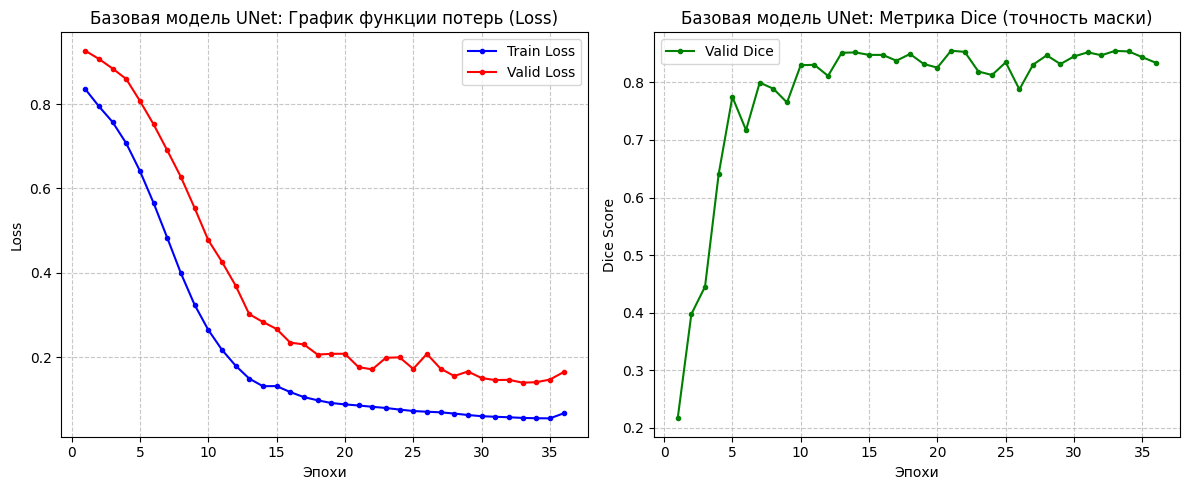

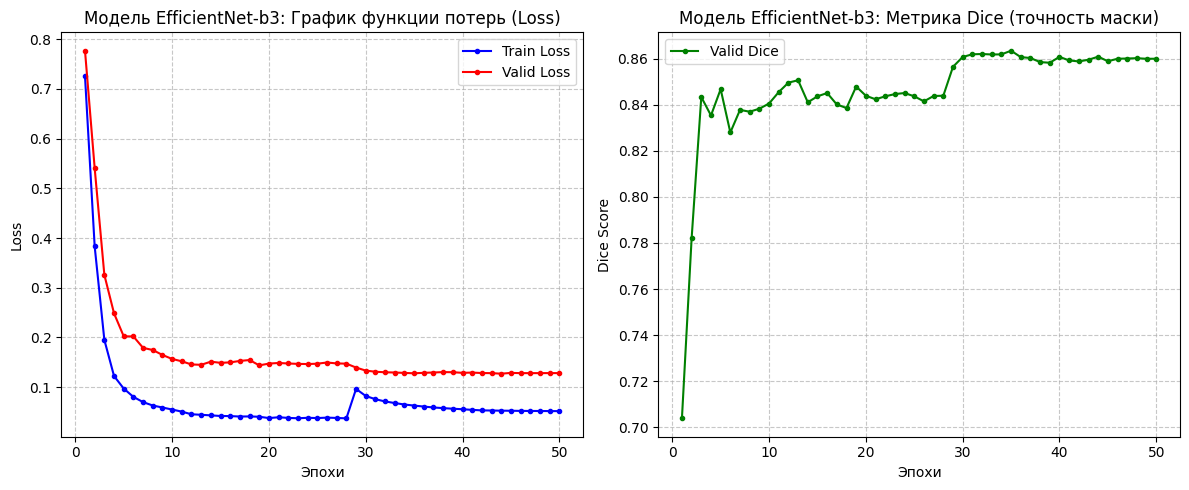

In [12]:
def plot_model_history(history, model_name):
    epochs_range = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue', marker='o', markersize=3)
    plt.plot(epochs_range, history['val_loss'], label='Valid Loss', color='red', marker='o', markersize=3)
    plt.title(f'{model_name}: График функции потерь (Loss)')
    plt.xlabel('Эпохи')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['val_dice'], label='Valid Dice', color='green', marker='o', markersize=3)
    plt.title(f'{model_name}: Метрика Dice (точность маски)')
    plt.xlabel('Эпохи')
    plt.ylabel('Dice Score')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()


plot_model_history(history_unet, "Базовая модель UNet")

history_effnet_full = {
    'train_loss': history_effnet_stage1['train_loss'] + history_effnet_stage2['train_loss'],
    'val_loss': history_effnet_stage1['val_loss'] + history_effnet_stage2['val_loss'],
    'val_dice': history_effnet_stage1['val_dice'] + history_effnet_stage2['val_dice']
}
plot_model_history(history_effnet_full, "Модель EfficientNet-b3")

**Вывод:**

- Базовая модель UNet достигает лучшего Dice ≈0.855 и служит сильным baseline`ом для задачи сегментации опухоли.
- Усложненная модель UnetPlusPlus с предобученным EfficientNet-b3 показывает чуть более высокий Dice ≈0.863 после дообучения, что подтверждает пользу использования предобученного энкодера и сложного декодера.
- Обе модели демонстрируют устойчивую сходимость: функции потерь на обучении и валидации снижаются и стабилизируются, а Dice выходит на плато без заметной деградации.
- Разница в качестве хоть и не огромная, но важная для медицинской задачи: усложненная модель лучше сегментирует малые и сложные по форме опухоли, поэтому ее можно считать предпочтительнее, а UNet надежным и интерпретируемым baseline`ом.


### Визуальный анализ предсказаний лучшей модели

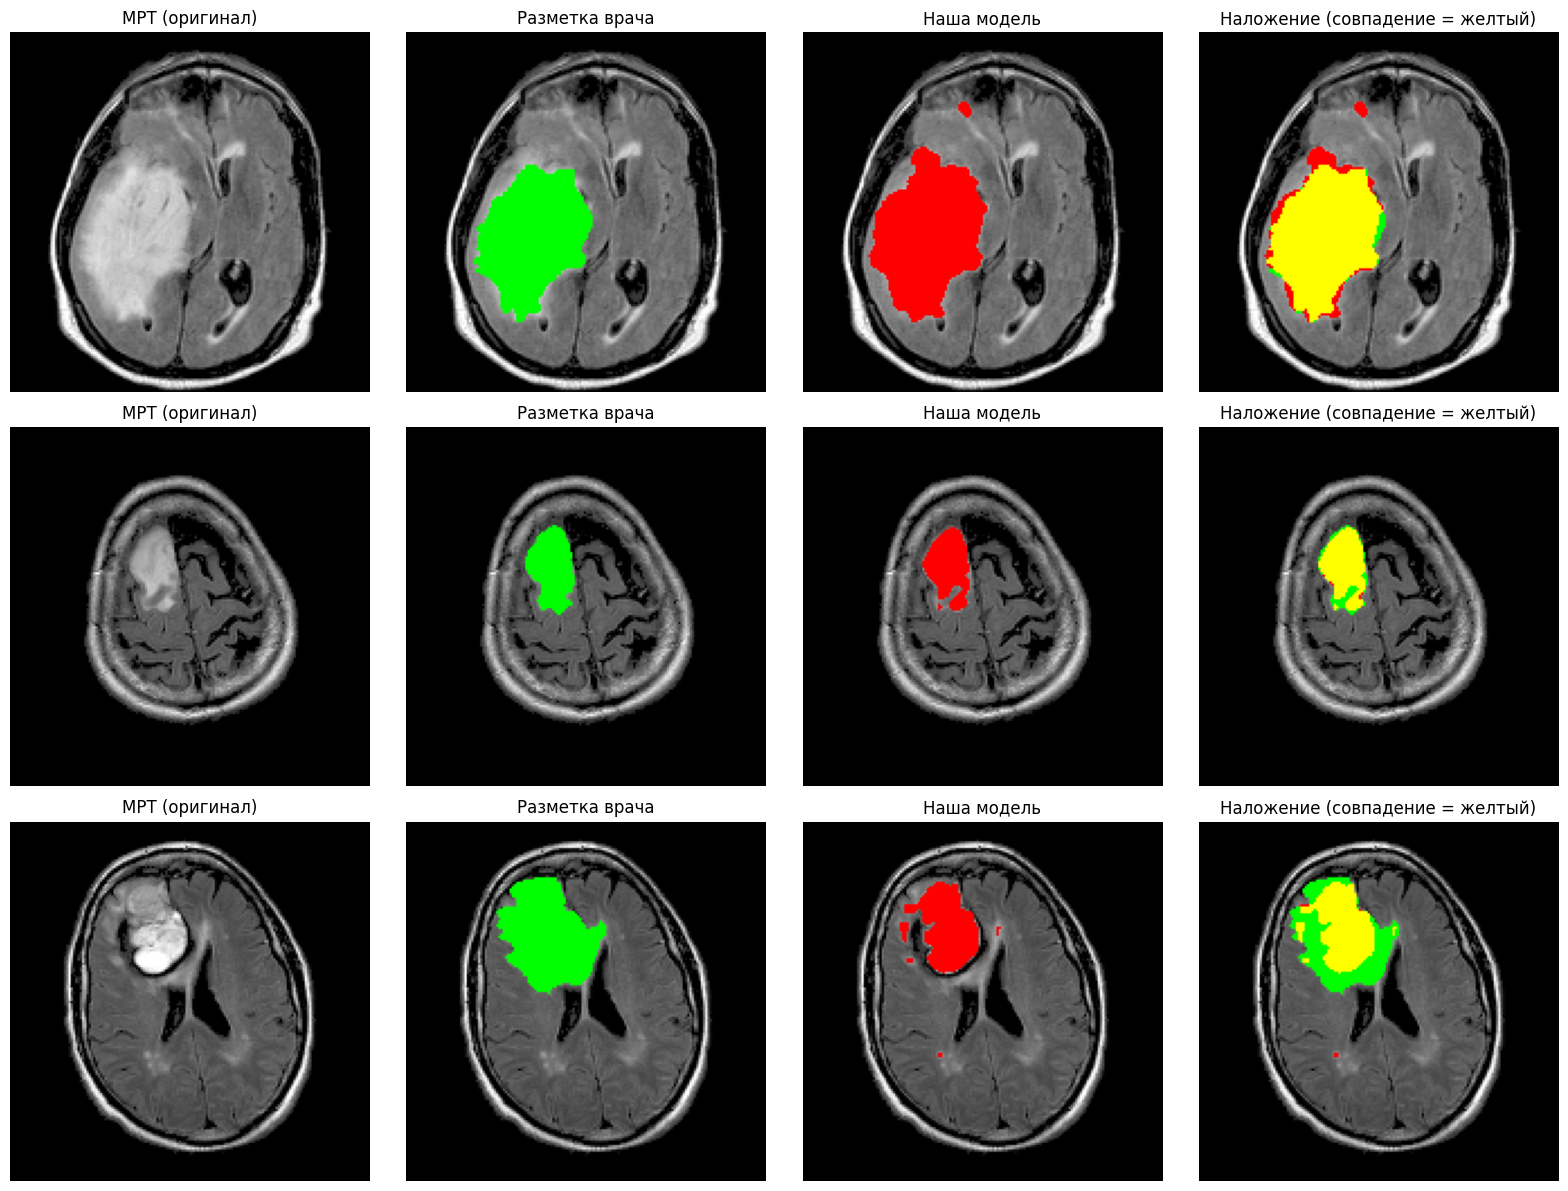

In [ ]:
def visualize_predictions(model_path, dataset_dict, num_samples=3):
    viz_dataset = FastBrainDataset(dataset_dict, transform=None, random_sampling=False)
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    model = smp.UnetPlusPlus(
        encoder_name="efficientnet-b3", 
        encoder_weights=None,
        in_channels=3, 
        classes=1, 
        activation='sigmoid'
    )
    
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    valid_indices_with_tumor = []
    for i in range(len(viz_dataset)):
        _, mask = viz_dataset[i]
        if mask.sum() > 0:
            valid_indices_with_tumor.append(i)
            
    indices = np.random.choice(valid_indices_with_tumor, num_samples, replace=False)

    plt.figure(figsize=(16, 4 * num_samples))
    
    for i, idx in enumerate(indices):
        image_tensor, mask_tensor = viz_dataset[idx]
        
        with torch.no_grad():
            imagenet_normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            x = imagenet_normalize(image_tensor).unsqueeze(0).to(device)
            pred = model(x)
            pred_mask = (pred.squeeze().cpu().numpy() > 0.5).astype(np.float32)
        
        img = image_tensor[1].numpy()
        true_mask = mask_tensor.squeeze().numpy()

        img_rgb = np.stack((img,)*3, axis=-1)
        img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min() + 1e-5)

        plt.subplot(num_samples, 4, i * 4 + 1)
        plt.imshow(img, cmap='gray')
        plt.title("МРТ (оригинал)")
        plt.axis('off')
        
        plt.subplot(num_samples, 4, i * 4 + 2)
        overlay_true = img_rgb.copy()
        overlay_true[true_mask == 1] = [0, 1, 0]
        plt.imshow(overlay_true)
        plt.title("Разметка врача")
        plt.axis('off')
        
        plt.subplot(num_samples, 4, i * 4 + 3)
        overlay_pred = img_rgb.copy()
        overlay_pred[pred_mask == 1] = [1, 0, 0]
        plt.imshow(overlay_pred)
        plt.title("Модель")
        plt.axis('off')
        
        plt.subplot(num_samples, 4, i * 4 + 4)
        overlay_blend = img_rgb.copy()
        overlay_blend[true_mask == 1] = [0, 1, 0]
        

        for y in range(pred_mask.shape[0]):
            for x in range(pred_mask.shape[1]):
                if pred_mask[y, x] == 1:
                    if true_mask[y, x] == 1:
                        overlay_blend[y, x] = [1, 1, 0]
                    else:
                        overlay_blend[y, x] = [1, 0, 0]
                        
        plt.imshow(overlay_blend)
        plt.title("Наложение (совпадение = желтый)")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

visualize_predictions("unetplusplus_finetuned_best.pt", valid_data, num_samples=3)


На примерах с валидационного набора видно, что UnetPlusPlus + EfficientNet-b3 после fine-tuning`а в большинстве случаев хорошо восстанавливает форму и расположение опухоли.  
Желтые области на итоговом наложении показывают пиксели, где предсказание точно совпадает с разметкой врача, зеленые — пропущенные участки опухоли, красные — ложноположительные пиксели модели.  
Для выбранных срезов преобладает желтый цвет, то есть модель уверенно находит основную массу опухоли; оставшиеся ошибки связаны с мелкими фрагментами и границами сегмента, что ожидаемо для задач медицинской сегментации.


#### Развитие:
В следующих этапах планируется реализовать систему поиска похожих случаев, объединив эмбеддинги из U-Net++ с клиническими данными из CSV-файла (возраст, пол, мутации). Это позволит системе искать релевантные случаи не только по визуальному сходству опухолей, но и с учетом клинических характеристик пациента.